In [1]:
# Install required packages
# sqldf allows us to write SQL queries on R dataframes
# ggplot2 is for creating charts in R
install.packages("sqldf")
install.packages("ggplot2")
install.packages("dplyr")

cat("✅ All packages installed!\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



✅ All packages installed!


In [3]:
# Load the packages
library(sqldf)
library(ggplot2)
library(dplyr)

# Load all datasets directly from GitHub
base_url <- "https://raw.githubusercontent.com/getdebugged/case_study/main/"

orders      <- read.csv(paste0(base_url, "orders.csv"))
deliveries  <- read.csv(paste0(base_url, "deliveries.csv"))
complaints  <- read.csv(paste0(base_url, "complaints.csv"))
customers   <- read.csv(paste0(base_url, "customers.csv"))
drivers     <- read.csv(paste0(base_url, "drivers.csv"))
hubs        <- read.csv(paste0(base_url, "hubs.csv"))
vehicles    <- read.csv(paste0(base_url, "vehicles.csv"))
incidents   <- read.csv(paste0(base_url, "incidents.csv"))

cat("✅ All datasets loaded!\n")
cat("Orders:", nrow(orders), "rows\n")
cat("Deliveries:", nrow(deliveries), "rows\n")
cat("Complaints:", nrow(complaints), "rows\n")

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




✅ All datasets loaded!
Orders: 1250 rows
Deliveries: 950 rows
Complaints: 320 rows


In [4]:
# LOOKS at the data
cat("Missing values in deliveries:", sum(is.na(deliveries)), "\n")
cat("Missing values in complaints:", sum(is.na(complaints)), "\n")

Missing values in deliveries: 14 
Missing values in complaints: 16 


## SQL in R Analysis
### SQL Query 1 - Delivery Status Summary

In [ ]:
# -------------------------------------------
# SQL IN R - USING sqldf PACKAGE
# sqldf lets us write real SQL queries
# directly on R dataframes
#------------------------------------------

# SQL Query 1 - Count deliveries by status
query1 <- sqldf("
  SELECT delivery_status,
         COUNT(*) AS total_deliveries,
         ROUND(AVG(fuel_or_charge_cost), 2) AS avg_fuel_cost,
         ROUND(AVG(route_distance_km), 2) AS avg_distance_km
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total_deliveries DESC
")

cat("=== Query 1: Delivery Status Summary ===\n")
print(query1)

=== Query 1: Delivery Status Summary ===
  delivery_status total_deliveries avg_fuel_cost avg_distance_km
1          OnTime              616         12.68           13.78
2         Delayed              202         13.14           14.67
3          Failed              132         13.15           13.37


Query 1: Failed deliveries cost slightly more in fuel (£13.15) and travel further when delayed (14.67km avg).

### SQL Query 2 - Hub Performance Analysis

In [ ]:
#------------------------------------------------
# SQL Query 2 - JOIN deliveries with hubs
# SQL JOIN between two tables
# We connect deliveries and hubs using hub_id
# to find which hub has most failures
#-------------------------------------------------

query2 <- sqldf("
  SELECT h.hub_name,
         h.zone,
         COUNT(*) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
         SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_deliveries,
         ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_fuel_cost
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_name, h.zone
  ORDER BY failed_deliveries DESC
")

cat("=== Query 2: Hub Performance ===\n")
print(query2)

=== Query 2: Hub Performance ===
        hub_name      zone total_deliveries failed_deliveries
1  Midtown Relay   Central              128                26
2   Central Core   Central              115                23
3 North Exchange     North              136                17
4      West Gate      West              127                16
5    Airport Hub   Airport              104                15
6  Riverside Hub Riverside              115                14
7      East Dock      East              119                11
8     South Link     South              106                10
  delayed_deliveries avg_fuel_cost
1                 22         11.71
2                 25         13.69
3                 26         12.76
4                 28         13.17
5                 27         13.32
6                 25         12.92
7                 23         12.74
8                 26         12.57


Query 2: Midtown Relay worst hub — 26 failures and 22 delays out of 128 deliveries. Central Core second worst.


### SQL Query 3 - Customer Complaints with Orders

In [ ]:
# ----------------------------------------------
# SQL Query 3 - JOIN complaints with orders
# Find which service types get most complaints
# -----------------------------------------------

query3 <- sqldf("
  SELECT o.service_type,
         COUNT(*) AS total_complaints,
         ROUND(AVG(c.resolution_days), 1) AS avg_resolution_days,
         SUM(c.compensation_amount) AS total_compensation
  FROM complaints c
  JOIN orders o ON c.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY total_complaints DESC
")

cat("=== Query 3: Complaints by Service Type ===\n")
print(query3)

=== Query 3: Complaints by Service Type ===
  service_type total_complaints avg_resolution_days total_compensation
1    Passenger               84                 7.7            1657.53
2       Retail               83                 7.9            1486.14
3       Parcel               77                 8.3            1463.65
4     Business               39                 7.9             810.86
5      Medical               37                 7.6             740.01


Query 3: Passenger service has most complaints (84) costing £1657 in compensation. Parcel complaints take longest to resolve (8.3 days).

### SQL Query 4 - Driver Performance

In [1]:
# -------------------------------------------------
# SQL Query 4 - JOIN deliveries with drivers
# Find which employment type performs best
#-------------------------------------------------

query4 <- sqldf("
  SELECT dr.employment_type,
         COUNT(*) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
         ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
         ROUND(AVG(dr.years_experience), 1) AS avg_experience_years
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY dr.employment_type
  ORDER BY failed DESC
")

cat("=== Query 4: Driver Performance by Employment Type ===\n")
print(query4)

ERROR: Error in sqldf("\n  SELECT dr.employment_type,\n         COUNT(*) AS total_deliveries,\n         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,\n         ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,\n         ROUND(AVG(dr.years_experience), 1) AS avg_experience_years\n  FROM deliveries d\n  JOIN drivers dr ON d.driver_id = dr.driver_id\n  GROUP BY dr.employment_type\n  ORDER BY failed DESC\n"): could not find function "sqldf"


Query 4: Full-time drivers have most failures (85) but only because they do most deliveries (582). Contract drivers actually have lowest rating (3.83).

## R Analytics and Visualisations

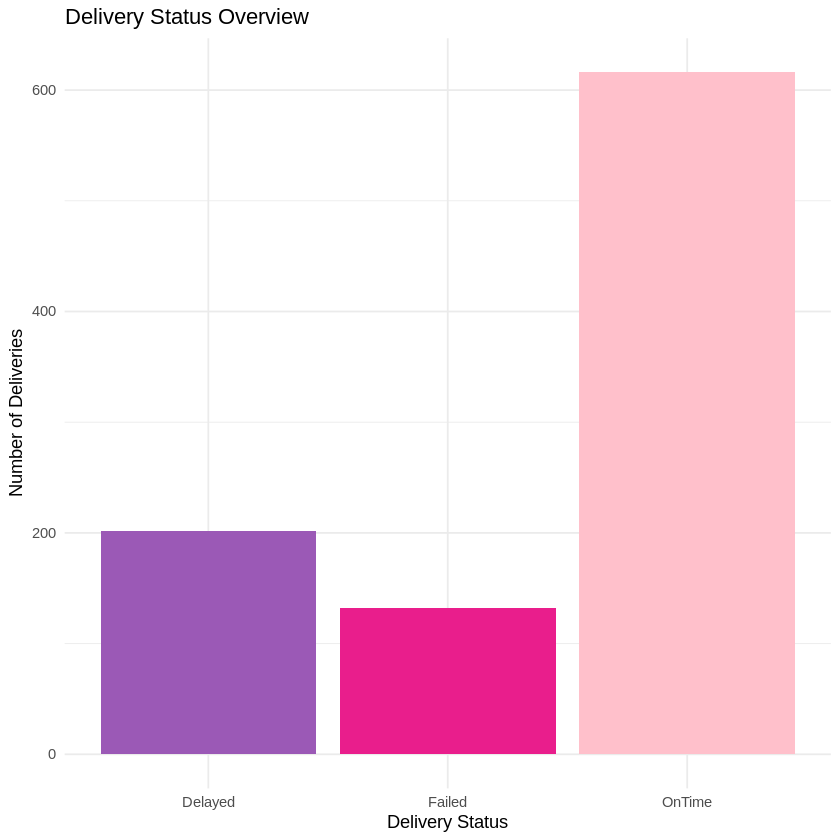

In [ ]:
# ---------------------------------------------
# R ANALYTICS - VISUALISATIONS
# ggplot2 is R's most powerful chart library
# ---------------------------------------------

# Chart 1 - Delivery Status Bar Chart
ggplot(data = as.data.frame(table(deliveries$delivery_status)),
       aes(x = Var1, y = Freq, fill = Var1)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Failed" = "#E91E8C",
                                "Delayed" = "#9B59B6",
                                "OnTime" = "pink")) +
  labs(title = "Delivery Status Overview",
       x = "Delivery Status",
       y = "Number of Deliveries") +
  theme_minimal() +
  theme(legend.position = "none")

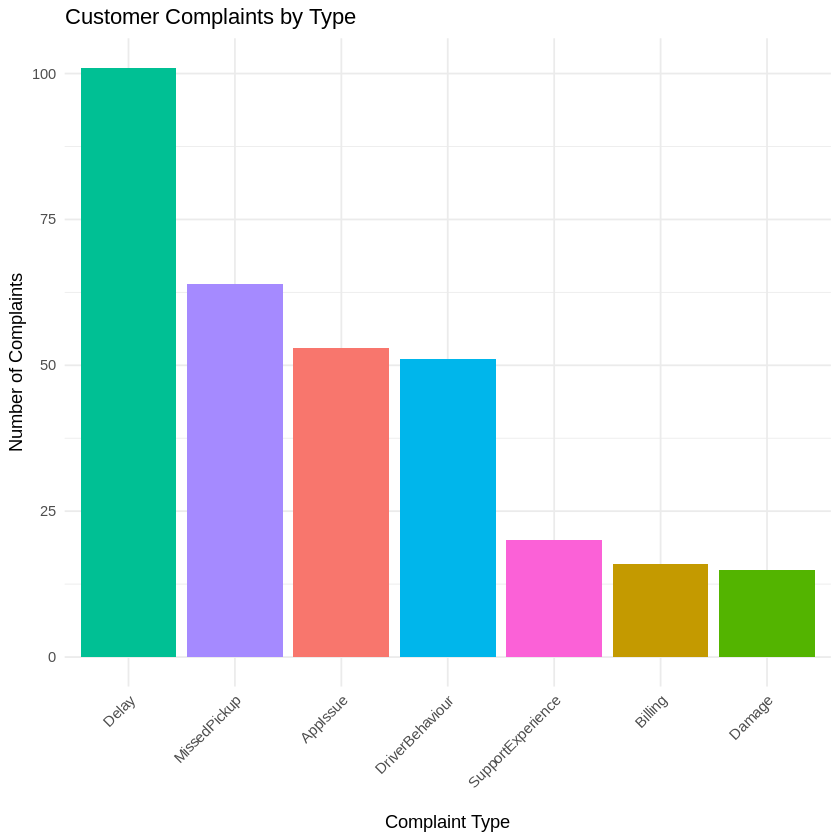

In [ ]:
# Chart 2 - Complaints by Type
complaint_counts <- as.data.frame(table(complaints$complaint_type))
colnames(complaint_counts) <- c("type", "count")
complaint_counts <- complaint_counts[order(-complaint_counts$count),]

ggplot(complaint_counts, aes(x = reorder(type, -count), y = count, fill = type)) +
  geom_bar(stat = "identity") +
  labs(title = "Customer Complaints by Type",
       x = "Complaint Type",
       y = "Number of Complaints") +
  theme_minimal() +
  theme(legend.position = "none",
        axis.text.x = element_text(angle = 45, hjust = 1))

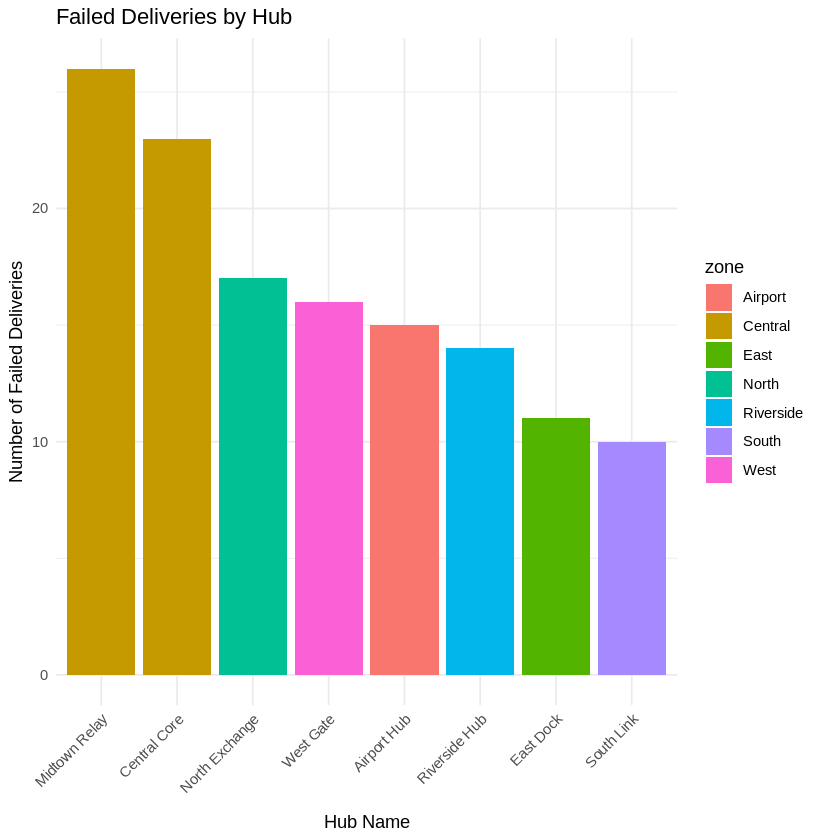

In [ ]:
# Chart 3 - Hub failures comparison
ggplot(query2, aes(x = reorder(hub_name, -failed_deliveries),
                   y = failed_deliveries, fill = zone)) +
  geom_bar(stat = "identity") +
  labs(title = "Failed Deliveries by Hub",
       x = "Hub Name",
       y = "Number of Failed Deliveries") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


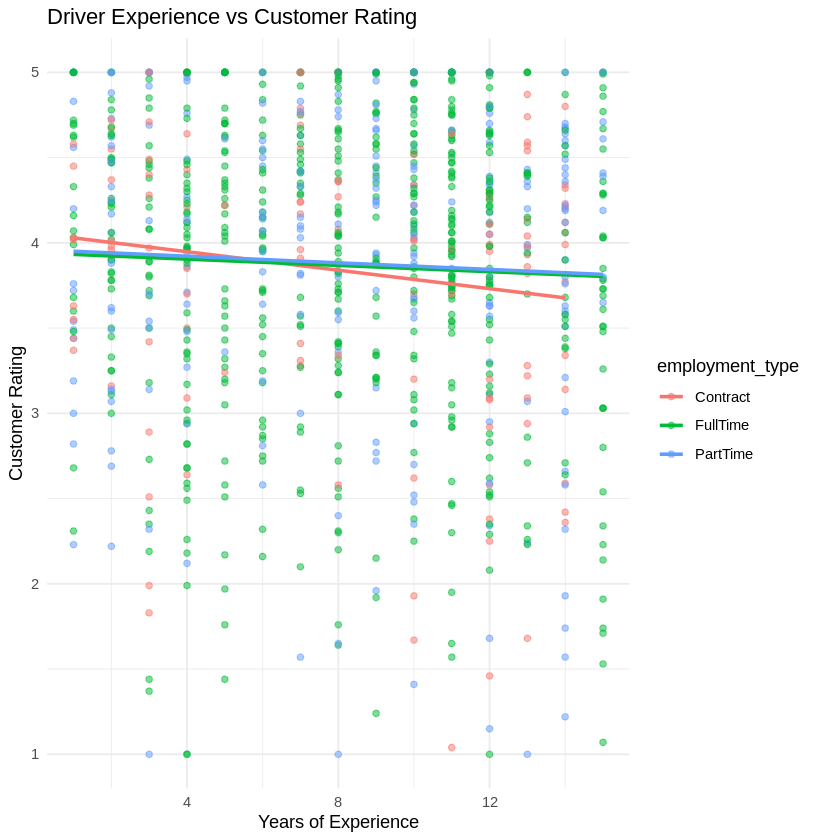

In [ ]:
# Chart 4 - Correlation between experience and rating
# merge drivers with deliveries first
driver_perf <- merge(deliveries, drivers, by = "driver_id")

ggplot(driver_perf, aes(x = years_experience,
                         y = customer_rating_post_delivery,
                         color = employment_type)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Driver Experience vs Customer Rating",
       x = "Years of Experience",
       y = "Customer Rating") +
  theme_minimal()

### Statistical Analysis - Complaint Resolution by Severity

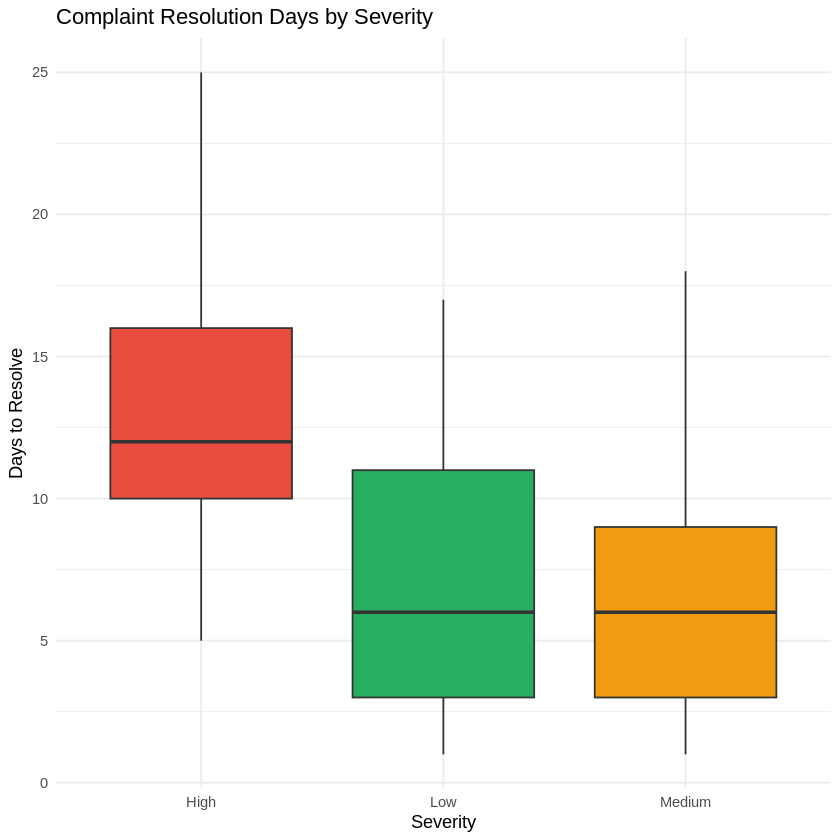

In [ ]:
# Chart 5 - Box plot showing resolution days by severity
# A box plot shows the spread of data
# The middle line = average, the box = most common range

ggplot(complaints, aes(x = severity, y = resolution_days, fill = severity)) +
  geom_boxplot() +
  scale_fill_manual(values = c("High" = "#E74C3C",
                                "Medium" = "#F39C12",
                                "Low" = "#27AE60")) +
  labs(title = "Complaint Resolution Days by Severity",
       x = "Severity",
       y = "Days to Resolve") +
  theme_minimal() +
  theme(legend.position = "none")

 Box Plot: High severity complaints take much longer to resolve (up to 25 days!) compared to Low severity. This shows NorthStar's complaint handling is inconsistent.

### Order Value Distribution by Service Type

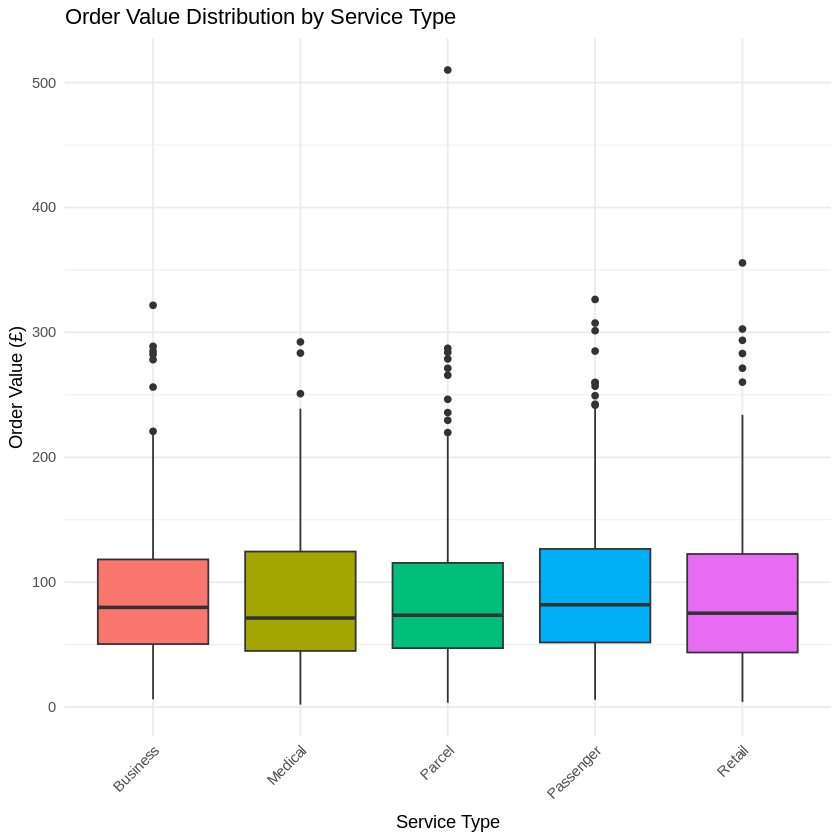

In [ ]:
# Chart 6 - Box plot of order values by service type
ggplot(orders, aes(x = service_type, y = order_value, fill = service_type)) +
  geom_boxplot() +
  labs(title = "Order Value Distribution by Service Type",
       x = "Service Type",
       y = "Order Value (£)") +
  theme_minimal() +
  theme(legend.position = "none",
        axis.text.x = element_text(angle = 45, hjust = 1))

Order Values: All service types have similar median order values around £80-100, but Passenger and Retail have the most outliers — some very high value orders that need special attention.

In [ ]:
### Summary Statistics

In [ ]:
# Key summary statistics for the report
cat("=== KEY SUMMARY STATISTICS ===\n\n")

cat("--- Delivery Performance ---\n")
cat("Total deliveries:", nrow(deliveries), "\n")
cat("Failed:", sum(deliveries$delivery_status == "Failed"), "\n")
cat("Delayed:", sum(deliveries$delivery_status == "Delayed"), "\n")
cat("Failure rate:", round(sum(deliveries$delivery_status == "Failed")/nrow(deliveries)*100, 1), "%\n\n")

cat("--- Complaints ---\n")
cat("Total complaints:", nrow(complaints), "\n")
cat("High severity:", sum(complaints$severity == "High"), "\n")
cat("Avg resolution days:", round(mean(complaints$resolution_days), 1), "\n")
cat("Total compensation paid: £", round(sum(complaints$compensation_amount), 2), "\n\n")

cat("--- Orders ---\n")
cat("Total orders:", nrow(orders), "\n")
cat("Average order value: £", round(mean(orders$order_value), 2), "\n")
cat("Critical priority orders:", sum(orders$priority_level == "Critical"), "\n")
# Fix compensation total
cat("Total compensation paid: £", round(sum(complaints$compensation_amount, na.rm = TRUE), 2), "\n")

=== KEY SUMMARY STATISTICS ===

--- Delivery Performance ---
Total deliveries: 950 
Failed: 132 
Delayed: 202 
Failure rate: 13.9 %

--- Complaints ---
Total complaints: 320 
High severity: 77 
Avg resolution days: 7.9 
Total compensation paid: £ NA 

--- Orders ---
Total orders: 1250 
Average order value: £ 91.05 
Critical priority orders: 91 
Total compensation paid: £ 6158.19 



###Delivery failure rate  -  13.9%
###Total failed deliveries  -  132 out of 950
###Total delayed deliveries  -  202 out of 950
###Worst hub  -  Midtown Relay (26 failures)
###Top complaint  -  Delay (101 complaints)
###Avg resolution time  -  7.9 days
###Total compensation paid-  -  £6,158.19
###Critical orders  -  91 out of 1250
###Fuel wasted on failures  -  £1,735.53